In [2]:
scenic = pd.read_csv('eRegulon_direct_guang.tsv', delimiter = '\t')

In [4]:
otohomo = pd.read_csv('OTO_star_nothreshold_missing_le2_expressionthresh_07062026.tsv',delimiter='\t',index_col = 'MM')

In [6]:
orthogroups = pd.read_csv('Vert_emapper_allorgs_07032026.tsv', delimiter = '\t',index_col = 'Unnamed: 0')

In [7]:
def orthogroup_mapper(orthogroups, label):
    mapping = {}
    for index in orthogroups.index:
        gene_list = orthogroups.loc[index, label]
        if type(gene_list) != float:
            genes = gene_list.split(',')
            for item in genes:
                mapping[item] = index
    return(mapping)

In [8]:
mm_mapping_ortho = orthogroup_mapper(orthogroups,'MM')
mo_mapping_ortho = orthogroup_mapper(orthogroups,'MO')
cj_mapping_ortho = orthogroup_mapper(orthogroups,'CJ')
ac_mapping_ortho = orthogroup_mapper(orthogroups,'AC')
xt_mapping_ortho = orthogroup_mapper(orthogroups,'XT')
dr_mapping_ortho = orthogroup_mapper(orthogroups,'DR')

In [1]:
!pip install anndata==0.8.0

  Using cached anndata-0.8.0-py3-none-any.whl (96 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 11.1 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: h5py
    Found existing installation: h5py 2.10.0
    Uninstalling h5py-2.10.0:
      Successfully uninstalled h5py-2.10.0
  Attempting uninstall: anndata
    Found existing installation: anndata 0.7.8
    Uninstalling anndata-0.7.8:
      Successfully uninstalled anndata-0.7.8
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
samap 1.0.2 requires h5py<=2.10, but you have h5py 3.8.0 which is incompatible.
sam-algorithm 1.0.0 requires h5py<=2.10.0, but you have h5py 3.8.0 which is incompatible.


In [2]:
!pip install openpyxl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.3/251.3 kB 1.5 MB/s eta 0:00:0000:0100:01


In [9]:
from samap.mapping import SAMAP
from samap.analysis import (get_mapping_scores, GenePairFinder, transfer_annotations,
                            sankey_plot, chord_plot, CellTypeTriangles, 
                            ParalogSubstitutions, FunctionalEnrichment,
                            convert_eggnog_to_homologs, GeneTriangles)
from samalg import SAM
import pandas as pd
from Bio import SeqIO
from samap.utils import (save_samap, load_samap)
import scanpy as sc
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
from scipy import sparse 
from scipy import cluster
import seaborn as sns
import random
import sklearn
from sklearn.neighbors import KernelDensity
import time
import dill
import pickle
from scipy.spatial import distance
import os
import scipy
from tqdm import tqdm
import matplotlib as mpl

In [10]:
sam_mg = SAM()
sam_mg.load_data('Active_SAM_joined/SAM_Allen_Institute_allhypo_01272026.h5ad')
gene_dict_mg = {}
for i in range(len(sam_mg.adata.var_names)):
    gene_dict_mg[sam_mg.adata.var_names[i]] = i

In [11]:
sam_mo = SAM()
sam_mo.load_data('Active_SAM_joined/SAM_MO_soupx_plus5_cleaned_NN_04142026.h5ad')
gene_dict_mo = {}
for i in range(len(sam_mo.adata.var_names)):
    gene_dict_mo[sam_mo.adata.var_names[i]] = i

In [12]:
sam_cj = SAM()
sam_cj.load_data('Active_SAM_joined/SAM_CJ_joined_v2_cleaned_geneexp_NN_06192025.h5ad')
gene_dict_cj = {}
for i in range(len(sam_cj.adata.var_names)):
    gene_dict_cj[sam_cj.adata.var_names[i]] = i

In [13]:
sam_ac= SAM()
sam_ac.load_data('Active_SAM_joined/SAM_AC_ncbi_soupx_cleaned_NN_geneexp_06192025.h5ad')
gene_dict_ac = {}
for i in range(len(sam_ac.adata.var_names)):
    gene_dict_ac[sam_ac.adata.var_names[i]] = i

In [14]:
sam_xt = SAM()
sam_xt.load_data('Active_SAM_joined/SAM_XT_joined_Slc17a6_cleaned_NN_geneexp_06192025.h5ad')
gene_dict_xt = {}
for i in range(len(sam_xt.adata.var_names)):
    gene_dict_xt[sam_xt.adata.var_names[i]] = i

In [15]:
sam_dr = SAM()
sam_dr.load_data('Active_SAM_joined/SAM_DR_ncbi_NN_geneexp_11202025.h5ad')
gene_dict_dr = {}
for i in range(len(sam_dr.adata.var_names)):
    gene_dict_dr[sam_dr.adata.var_names[i]] = i

In [23]:
TF = pd.read_csv('Fin_TF_06012026.csv')
TF = TF.rename(columns={'0': 0})
TF_set = set(TF[0]) & set(otohomo.index)
neuropep = pd.read_csv('Neuropeptides_receptors_10202025.csv')
neuropep_list = list(neuropep['Neuropeptide names'].unique())

In [24]:
len(TF_set)

859

In [25]:
exp = sam_mg.adata.X.A
all_exp_ct = np.zeros((sam_mg.adata.obs['subclass_id_label'].nunique(),len(sam_mg.adata.var_names)))
ctl = sam_mg.adata.obs['subclass_id_label'].unique()
for i in range(len(ctl)):
    all_exp_ct[i,:] = np.average(exp[sam_mg.adata.obs['subclass_id_label'] == ctl[i],:], axis = 0)

In [79]:
scenic_np_tf = []
mg_vals = []
for g in neuropep_list:
    scg = list(scenic['Gene'])
    if g in scg:
        if len(set(scenic[scenic['Gene'] == g]['TF'])& TF_set) > 0 and g in otohomo.index:
            for item in set(scenic[scenic['Gene'] == g]['TF'])& TF_set:
                if stats.pearsonr(all_exp_ct[:,gene_dict_mg[g]], all_exp_ct[:,gene_dict_mg[item]])[0] > .3 and (scenic[(scenic['Gene'] == g) & (scenic['TF'] == item)]['regulation'] == 1).all():
                    scenic_np_tf.append((g,item))
                    mg_vals.append(stats.pearsonr(all_exp_ct[:,gene_dict_mg[g]], all_exp_ct[:,gene_dict_mg[item]])[0])

/scratch/miniconda/lib/python3.7/site-packages/scipy/stats/stats.py:4023: PearsonRConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(PearsonRConstantInputWarning())


In [100]:
scenic_np_tf

[('Agrp', 'Fli1'),
 ('Apln', 'Nkx2-2'),
 ('Avp', 'Fosl2'),
 ('Cck', 'Hlf'),
 ('Crh', 'Pou3f2'),
 ('Crh', 'Nr3c1'),
 ('Gal', 'Isl1'),
 ('Gal', 'Esr1'),
 ('Gnrh1', 'Otx1'),
 ('Gnrh1', 'Isl1'),
 ('Igf1', 'Nkx2-1'),
 ('Nmu', 'Nkx2-1'),
 ('Npvf', 'Nkx2-2'),
 ('Npvf', 'Lhx9'),
 ('Npvf', 'Hmx2'),
 ('Npvf', 'Hmx3'),
 ('Oxt', 'Fosl2'),
 ('Pdyn', 'Nkx2-1'),
 ('Pomc', 'Esr1'),
 ('Prok2', 'Pparg'),
 ('Prok2', 'Foxn4'),
 ('Prok2', 'Nr1d1'),
 ('Prok2', 'Dbp'),
 ('Tac1', 'Ar'),
 ('Tac2', 'Nr5a2'),
 ('Tac2', 'Ar'),
 ('Vgf', 'Fosl2'),
 ('Vgf', 'Fos'),
 ('Qrfp', 'Lhx9'),
 ('Qrfp', 'Rfx2'),
 ('Dbi', 'Tcf12')]

In [101]:
scenic_np_tf_flat = [item for tup in scenic_np_tf for item in tup]

In [102]:
mg_exp ={i:i for i in scenic_np_tf_flat}
mo_exp = {i:otohomo.loc[i,'MO'] for i in scenic_np_tf_flat}
cj_exp = {i:otohomo.loc[i,'CJ'] for i in scenic_np_tf_flat}
ac_exp = {i:otohomo.loc[i,'AC'] for i in scenic_np_tf_flat}
xt_exp = {i:otohomo.loc[i,'XT'] for i in scenic_np_tf_flat}
dr_exp = {i:otohomo.loc[i,'DR'] for i in scenic_np_tf_flat}

In [103]:
df_corr = pd.DataFrame(columns = ['mm','mo','cj','ac','xt','dr'], index = scenic_np_tf)

In [104]:
df_corr['mm'] = mg_vals

In [105]:
df_corr

,mm,mo,cj,ac,xt,dr
"(Agrp, Fli1)",0.621393,NaN,NaN,NaN,NaN,NaN
"(Apln, Nkx2-2)",0.361732,NaN,NaN,NaN,NaN,NaN
"(Avp, Fosl2)",0.313507,NaN,NaN,NaN,NaN,NaN
"(Cck, Hlf)",0.350974,NaN,NaN,NaN,NaN,NaN
"(Crh, Pou3f2)",0.411288,NaN,NaN,NaN,NaN,NaN
"(Crh, Nr3c1)",0.361370,NaN,NaN,NaN,NaN,NaN
"(Gal, Isl1)",0.309489,NaN,NaN,NaN,NaN,NaN
"(Gal, Esr1)",0.424799,NaN,NaN,NaN,NaN,NaN
"(Gnrh1, Otx1)",0.897795,NaN,NaN,NaN,NaN,NaN
"(Gnrh1, Isl1)",0.324328,NaN,NaN,NaN,NaN,NaN


In [106]:
def corr_org(org, adata, gene_name_conv, level, glist):
    fin_df = pd.DataFrame(index = glist, columns = [org])
    gene_dict = {gene: idx for idx, gene in enumerate(adata.var_names)}
    exp = adata.X.A
    all_exp_ct = np.zeros((adata.obs[level].nunique(),len(adata.var_names)))
    ctl = adata.obs[level].unique()
    for i in range(len(ctl)):
        all_exp_ct[i,:] = np.average(exp[adata.obs[level] == ctl[i],:], axis = 0)
    for item in glist:
        g1 = gene_name_conv[item[0]]
        g2 = gene_name_conv[item[1]]
        if type(g1) == str and type(g2) == str and g1 in gene_dict and g2 in gene_dict:
            fin_df.loc[[tuple(item)], org] = stats.pearsonr(all_exp_ct[:,gene_dict[g1]], all_exp_ct[:,gene_dict[g2]])[0]
    return(fin_df)

In [107]:
sam_cj.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_genes', 'n_counts',
       'key', 'hicat_merged', 'subclass_id_label_mapping',
       'subclass_id_label_lc', 'leiden_clusters',
       'subclass_id_label_mapping_nounlabeled', 'neurotransmitter',
       'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled', 'fraction_match',
       'best_match', 'frac_match_test', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'eq_subclass_nounlabeled_NN',
       'eq_subclass_nounlabeled_nmm', 'ss_subclass', 'ss_subclass_nounlabeled',
       'ss_class', 'ss_subclass_nounlabeled_astro', 'ss_subclass_v2',
       'ss_subclass_v2_nounlabeled', 'ss_subclass_nounlabeled_nmm',
       'ss_subclass_v3_nounlabeled', 'subclass_id_label_crossed',
       'ss_subclas

In [108]:
with open('parent_dict.pkl', 'rb') as f:
    parent_dict = pickle.load(f)

In [114]:
sam_mo.adata.obs.columns

Index(['orig.ident', 'nCount_RNA', 'nFeature_RNA', 'n_counts', 'n_genes',
       'key', 'subclass_id_label_mapping', 'subclass_id_label_lc',
       'leiden_clusters', 'subclass_id_label_mapping_nounlabeled',
       'neurotransmitter', 'region_label', 'subclass_id_label_reduced_mapping',
       'subclass_id_label_reduced_lc',
       'subclass_id_label_reduced_mapping_nounlabeled',
       'leiden_clusters_formarkers', 'leiden_removal', 'nCount_SCT',
       'nFeature_SCT', 'SCT_snn_res.0.8', 'seurat_clusters', 'SCT_snn_res.5',
       'eq_subclass', 'eq_subclass_lc', 'eq_subclass_frac',
       'eq_subclass_nounlabeled', 'NN', 'ss_subclass',
       'ss_subclass_nounlabeled', 'ss_subclass_nounlabeled_03102026',
       'ss_subclass_nounlabeled_03102026_crossed', 'neurotransmitter_v2'],
      dtype='object')

In [115]:
for item in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique():
    if item not in parent_dict.keys():
        parent_dict[item] = 'hypo'
    if item[:2] == 'mo':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mg':
        parent_dict[item] = 'hypo'
    if item[:2] == 'xt':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ac':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cj':
        parent_dict[item] = 'hypo'
    if item[:2] == 'dr':
        parent_dict[item] = 'hypo'
    if item[:2] == 'mv':
        parent_dict[item] = 'hypo'
    if item[:2] == 'cc':
        parent_dict[item] = 'hypo'
    if item[:2] == 'rv':
        parent_dict[item] = 'hypo'
    if item[:2] == 'ri':
        parent_dict[item] = 'hypo'

In [116]:
parent_dict['not hypo'] = 'not hypo'
parent_dict['hypo'] = 'hypo'
parent_dict['Unknown'] = 'hypo'
parent_dict['Unknwon_2'] = 'hypo'
parent_dict['Non neuron'] = 'not hypo'

In [117]:
hl_mo = [i for i in sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_cj = [i for i in sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_ac = [i for i in sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_xt = [i for i in sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']
hl_dr = [i for i in sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].unique() if parent_dict[parent_dict[i]] == 'hypo']

mo_hypo_adata = sam_mo.adata[sam_mo.adata.obs['ss_subclass_nounlabeled_03102026'].isin(hl_mo)]
cj_hypo_adata = sam_cj.adata[sam_cj.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_cj)]
ac_hypo_adata = sam_ac.adata[sam_ac.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_ac)]
xt_hypo_adata = sam_xt.adata[sam_xt.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_xt)]
dr_hypo_adata = sam_dr.adata[sam_dr.adata.obs['ss_subclass_nounlabeled_nmm_v3_nn'].isin(hl_dr)]

In [118]:
df_corr['mo'] = corr_org('mo',mo_hypo_adata,mo_exp,'ss_subclass_nounlabeled_03102026',df_corr.index)
df_corr['cj'] = corr_org('cj',cj_hypo_adata,cj_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)
df_corr['ac'] = corr_org('ac',ac_hypo_adata,ac_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)
df_corr['xt'] = corr_org('xt',xt_hypo_adata,xt_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)
df_corr['dr'] = corr_org('dr',dr_hypo_adata,dr_exp,'ss_subclass_nounlabeled_nmm_v3_nn',df_corr.index)

In [119]:
df_corr = df_corr.T

In [120]:
swapped = [(b, a) for a, b in df_corr.columns]

# 2. Sort by the new first element (stable sort preserves relative order
#    within each group)
sorted_swapped = sorted(range(len(swapped)), key=lambda i: swapped[i][0])

# 3. Reindex columns
df_swapped = df_corr.iloc[:, sorted_swapped]

In [121]:
dfcorr_flat = list(set([item for tup in df_swapped.columns for item in tup]))

In [122]:
df_swapped

,"(Tac1, Ar)","(Tac2, Ar)","(Prok2, Dbp)","(Gal, Esr1)","(Pomc, Esr1)","(Agrp, Fli1)","(Vgf, Fos)","(Avp, Fosl2)","(Oxt, Fosl2)","(Vgf, Fosl2)",...,"(Apln, Nkx2-2)","(Npvf, Nkx2-2)","(Prok2, Nr1d1)","(Crh, Nr3c1)","(Tac2, Nr5a2)","(Gnrh1, Otx1)","(Crh, Pou3f2)","(Prok2, Pparg)","(Qrfp, Rfx2)","(Dbi, Tcf12)"
mm,0.405647,0.309298,0.5974,0.424799,0.332997,0.621393,0.397635,0.313507,0.446301,0.504516,...,0.361732,0.848023,0.732503,0.36137,0.314587,0.897795,0.411288,0.513059,0.466379,0.44483
mo,-0.029635,0.363362,0.584099,0.161575,0.378798,-0.023448,0.596499,0.502868,0.504534,0.160793,...,-0.106819,0.178497,0.586573,0.093301,-0.067749,0.051493,0.296989,0.237457,0.453217,0.186556
cj,-0.133082,NaN,NaN,0.204895,0.364221,0.173218,NaN,0.079266,0.007874,NaN,...,0.212597,0.24535,0.146581,-0.051357,NaN,0.082487,0.053573,-0.061938,0.553362,0.093397
ac,0.03995,-0.070885,-0.041549,-0.011334,-0.049439,0.000812,0.363112,0.243679,0.190604,0.267058,...,NaN,0.435344,-0.127218,-0.044908,-0.063537,NaN,0.113215,-0.05721,NaN,-0.104687
xt,-0.082981,-0.080483,0.052397,-0.032104,0.044914,0.054258,0.3302,0.228089,0.143322,0.478085,...,0.146253,0.238431,0.066967,0.012333,-0.014465,0.777094,0.153849,0.132124,0.23123,0.116055
dr,0.187657,NaN,NaN,0.104263,-0.093389,0.00298,0.177499,0.120723,0.033769,0.17389,...,NaN,NaN,-0.049994,-0.055129,NaN,NaN,0.065537,0.06305,NaN,0.103446


In [123]:
df_swapped = df_swapped.astype(float)

In [124]:
df_swapped.to_csv('Neuropep_TF_corr_hypo_07072026.csv')

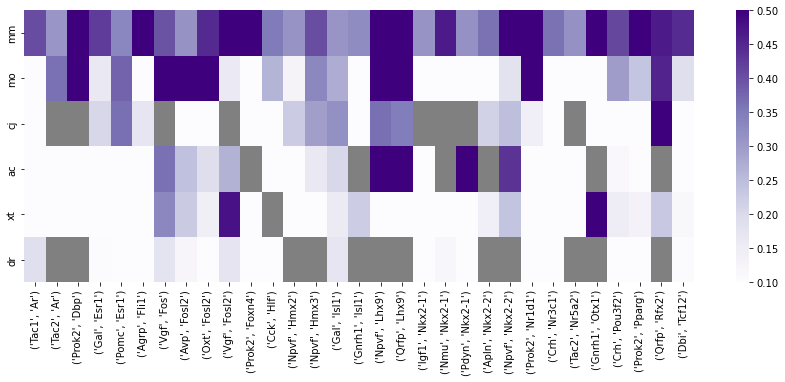

In [126]:
plt.figure(figsize =(15,5))

cmap = mpl.cm.get_cmap("Purples").copy()
cmap.set_bad('grey')  # sets NaN color

sns.heatmap(df_swapped, cmap = cmap, vmax = .5, vmin = 0.1)
plt.savefig('Figures/Figures_07072026/NP_TF_relationship_07072026.svg')
plt.savefig('Figures/Figures_07072026/NP_TF_relationship_07072026.pdf')

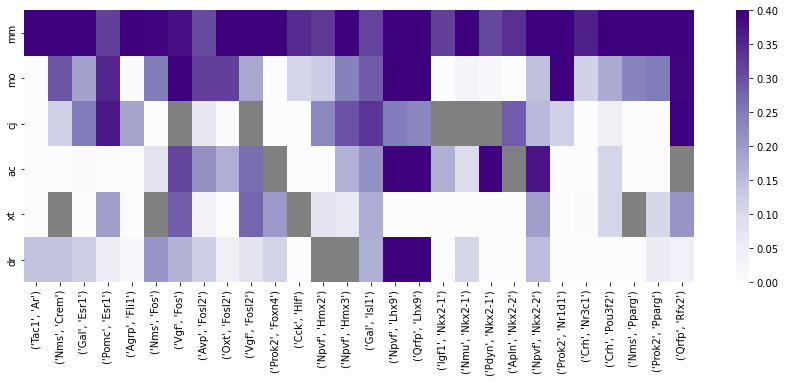

In [67]:
plt.figure(figsize =(15,5))

cmap = mpl.cm.get_cmap("Purples").copy()
cmap.set_bad('grey')  # sets NaN color

sns.heatmap(df_swapped, cmap = cmap, vmax = .4, vmin = 0)
plt.savefig('Figures/Figures_03202026/NP_TF_relationship_03152026.svg')

In [69]:
df_swapped.columns

Index([    ('Tac1', 'Ar'),     ('Tac2', 'Ar'),   ('Prok2', 'Dbp'),
          ('Gal', 'Esr1'),   ('Pomc', 'Esr1'),   ('Agrp', 'Fli1'),
           ('Vgf', 'Fos'),   ('Avp', 'Fosl2'),   ('Oxt', 'Fosl2'),
         ('Vgf', 'Fosl2'), ('Prok2', 'Foxn4'),     ('Cck', 'Hlf'),
         ('Npvf', 'Hmx2'),   ('Npvf', 'Hmx3'),    ('Gal', 'Isl1'),
        ('Gnrh1', 'Isl1'),   ('Npvf', 'Lhx9'),   ('Qrfp', 'Lhx9'),
       ('Igf1', 'Nkx2-1'),  ('Nmu', 'Nkx2-1'), ('Pdyn', 'Nkx2-1'),
       ('Apln', 'Nkx2-2'), ('Npvf', 'Nkx2-2'), ('Prok2', 'Nr1d1'),
         ('Crh', 'Nr3c1'),  ('Tac2', 'Nr5a2'),  ('Gnrh1', 'Otx1'),
        ('Crh', 'Pou3f2'), ('Prok2', 'Pparg'),   ('Qrfp', 'Rfx2'),
         ('Apln', 'Sox4'),   ('Dbi', 'Tcf12')],
      dtype='object')

In [71]:
#test
scenic[scenic['Gene'] == 'Tac1']['TF']

1226         Ar
1955         Ar
6160       Ebf2
32293    Nkx2-1
80239     Sox14
Name: TF, dtype: object

In [78]:
(scenic[(scenic['Gene'] == 'Tac1') & (scenic['TF'] == 'Ar')]['regulation'] == 1).all()

True